<a href="https://colab.research.google.com/github/vivilchesm-rgb/MineriaEvaluacion/blob/vicente-vilches/MovieBudget.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Importación y Carga de dataset

In [ ]:
#Importamos las librerias necesarias para realizar los diversos analisis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Ajustamos la visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [ ]:
#Cargamos el dataset
df = pd.read_csv("/content/expensive_movie.csv")

In [ ]:
#Revisamos la cantidad de filas y columnas del dataset
print(f"Dimensiones del dataset: {df.shape}")

Dimensiones del dataset: (8121, 17)


In [ ]:
#Visualizamos las primeras filas para obtener información de estas
display(df.head())

,ID,Title,Original_Language,Release_Date,Popularity,Vote_Average,Vote_Count,Runtime,Budget,Revenue,Status,Tagline,Overview,Genres,Production_Companies,Production_Countries,Spoken_Languages
0,969681,Spider-Man: Brand New Day,en,2026-07-29,81.5967,0.000,0,0,0,0,Post Production,A brand new day starts now.,Four years have passed since the events of No ...,"Science Fiction, Action, Adventure","Marvel Studios, Columbia Pictures, Pascal Pict...",United States of America,English
1,1242898,Predator: Badlands,en,2025-11-05,78.4384,7.704,2424,107,105000000,184500000,Released,First hunt. Last chance.,"Cast out from his clan, a young Predator finds...","Action, Science Fiction, Adventure","20th Century Studios, Lawrence Gordon Producti...",United States of America,"French, English"
2,11375,Hollywood Homicide,en,2003-06-09,62.2209,5.238,686,116,75000000,51142659,Released,They're two cops with one shot at solving a mu...,"Joe Gavilan and his new partner K. C. Calden, ...","Action, Adventure, Comedy, Thriller",Revolution Studios,United States of America,English
3,7451,xXx,en,2002-08-09,61.1958,5.980,4821,124,70000000,277448382,Released,A new breed of secret agent.,Xander Cage is your standard adrenaline junkie...,"Action, Adventure, Thriller, Crime, Drama",Revolution Studios,United States of America,"Czech, English, German, Spanish, Russian"
4,458576,Monster Hunter,en,2020-12-03,52.1623,6.526,3508,103,60000000,42145959,Released,"Behind our world, there is another.",A portal transports Cpt. Artemis and an elite ...,"Action, Fantasy, Adventure","Capcom, Constantin Film, Tencent Pictures, TOH...","China, Germany, Japan, Canada",English


In [ ]:
#Visualizamos las ultimas filas para obtener información de estas
display(df.tail())

,ID,Title,Original_Language,Release_Date,Popularity,Vote_Average,Vote_Count,Runtime,Budget,Revenue,Status,Tagline,Overview,Genres,Production_Companies,Production_Countries,Spoken_Languages
8116,440943,Johnny Thunder and the Wisdom of the Ancients,en,2014-08-22,0.0,0.0,0,87,0,0,Released,The hidden mysteries await...,Johhny Thunder and the gang search for the key...,"Action, Adventure, Animation",NaN,NaN,NaN
8117,331766,Rage Brothers,en,2009-07-26,0.0,0.0,0,132,0,0,Released,The End of an Age,Seven years have passed since the epic struggl...,"Comedy, Action, Adventure",NaN,NaN,NaN
8118,323953,KIKIBUTI,en,2012-03-31,0.0,0.0,0,120,1000000,0,Released,Little Land of Hope,"Once upon a time in this primitive story, A vi...","Thriller, Adventure, Action","Magnificent Creations Multimedia, Dodzi Networ...",Ghana,"Akan, English, Ewe"
8119,271527,Bleeding Iowa,en,1999-01-01,0.0,0.0,0,0,0,0,Released,NaN,A convicted felon is set free by the FBI to un...,"Action, Adventure",NaN,NaN,NaN
8120,87609,Duct Wars: The Silver Enemy,en,2000-04-23,0.0,0.0,0,41,0,0,Released,NaN,Juan Zi Nobie and Dantin have retired from act...,"Action, Science Fiction, Adventure",DCJ Productions,United States of America,English


##2. Verificación de Datos Inicial

In [ ]:
#Verificamos los tipos de datos con los que estamos tratando
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8121 entries, 0 to 8120
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    8121 non-null   int64  
 1   Title                 8121 non-null   object 
 2   Original_Language     8121 non-null   object 
 3   Release_Date          7760 non-null   object 
 4   Popularity            8121 non-null   float64
 5   Vote_Average          8121 non-null   float64
 6   Vote_Count            8121 non-null   int64  
 7   Runtime               8121 non-null   int64  
 8   Budget                8121 non-null   int64  
 9   Revenue               8121 non-null   int64  
 10  Status                8121 non-null   object 
 11  Tagline               3425 non-null   object 
 12  Overview              7734 non-null   object 
 13  Genres                8118 non-null   object 
 14  Production_Companies  6594 non-null   object 
 15  Production_Countries 

###Diccionario de Datos (Mapeo de Columnas)
Hacer este mapeo o diccionario de datos es fundamental para entender bien de qué trata nuestro proyecto. Nos sirve para ponernos de acuerdo en qué significa cada columna y saber si estamos trabajando con números o categorías.

| Nombre de Columna | Descripción | Variable Estadística | Tipo Informático (Dtype) |
| :--- | :--- | :--- | :--- |
| `ID` | Identificador único de la película. | Numérica (ID) | `int64` |
| `Title` | Nombre oficial de la producción. | Categórica Nominal | `object (string)` |
| `Original_Language` | Código del idioma original (ej. 'en', 'zh'). | Categórica Nominal | `object (string)` |
| `Original_Language_encoded` | Código del idioma original (ej. '1', '2'). | Categórica Nominal | `object (string)` |
| `Release_Date` | Fecha de estreno oficial. | Categórica (Temporal) | `object (datetime)` |
| `Popularity` | Índice de tendencia/vistas en la base de datos. | Numérica Continua | `float64` |
| `Vote_Average` | Calificación promedio otorgada por usuarios. | Numérica Continua | `float64` |
| `Vote_Count` | Cantidad total de votos registrados. | Numérica Discreta | `int64` |
| `Runtime` | Duración de la película en minutos. | Numérica Discreta | `int64` |
| `Budget` | Presupuesto total de producción en USD. | Numérica Continua | `int64 / float64` |
| `Revenue` | Ingresos totales recaudados en taquilla. | Numérica Continua | `int64 / float64` |
| `Status` | Estado de la película (Released, Post Production). | Categórica Nominal | `object (string)` |
| `Genres` | Lista de géneros asociados a la cinta. | Categórica (Multivalor) | `object (string)` |

---

In [ ]:
#Identificar valores nulos en el dataset
print("Conteo de valores nulos por columna:")
print(df.isnull().sum())

Conteo de valores nulos por columna:
ID                         0
Title                      0
Original_Language          0
Release_Date             361
Popularity                 0
Vote_Average               0
Vote_Count                 0
Runtime                    0
Budget                     0
Revenue                    0
Status                     0
Tagline                 4696
Overview                 387
Genres                     3
Production_Companies    1527
Production_Countries    1046
Spoken_Languages         876
dtype: int64


##3. Limpieza y Transformación

In [ ]:
#Eliminamos columnas irrelevantes
df_limpio = df.drop(columns=['Tagline', 'Overview', 'Production_Companies'])

#En lugar de filtrar ceros, filtramos solo los valores REALMENTE nulos (NaN) que impiden el análisis, como la fecha de estreno o géneros.
df_limpio = df_limpio.dropna(subset=['Release_Date', 'Genres'])

#Generamos una columna nueva para comprobar las ganancias
df_limpio['Profit'] = df_limpio['Revenue'] - df_limpio['Budget']

print(f"Registros iniciales: {len(df)}")
print(f"Registros para análisis: {len(df_limpio)}")

Registros iniciales: 8121
Registros para análisis: 7760


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['Original_Lenguaje_Encoded'] = label_encoder.fit_transform(df['Original_Language'])

print("Mapeo de Original_Language:")
for i, item in enumerate(label_encoder.classes_):
    print(f"{item} : {i}")

Mapeo de Original_Language:
af : 0
ar : 1
as : 2
az : 3
bg : 4
bn : 5
bo : 6
br : 7
cn : 8
cs : 9
da : 10
de : 11
el : 12
en : 13
es : 14
et : 15
fa : 16
fi : 17
fr : 18
gl : 19
gu : 20
he : 21
hi : 22
hr : 23
hu : 24
hy : 25
id : 26
is : 27
it : 28
ja : 29
ka : 30
kk : 31
kl : 32
kn : 33
ko : 34
ku : 35
lt : 36
lv : 37
mi : 38
mk : 39
ml : 40
mn : 41
ms : 42
mt : 43
my : 44
nb : 45
nl : 46
no : 47
pa : 48
pl : 49
pt : 50
ro : 51
ru : 52
si : 53
sk : 54
sl : 55
sr : 56
sv : 57
sw : 58
ta : 59
te : 60
th : 61
tl : 62
tr : 63
uk : 64
ur : 65
vi : 66
xx : 67
zh : 68
zu : 69


In [ ]:
# Verificamos que las nuevas columnas codificadas se hayan integrado bien
display(df[['Original_Lenguaje_Encoded', 'Original_Language']].head())

,Original_Lenguaje_Encoded,Original_Language
0,13,en
1,13,en
2,13,en
3,13,en
4,13,en


#4. Analisis Exploratorio de Datos


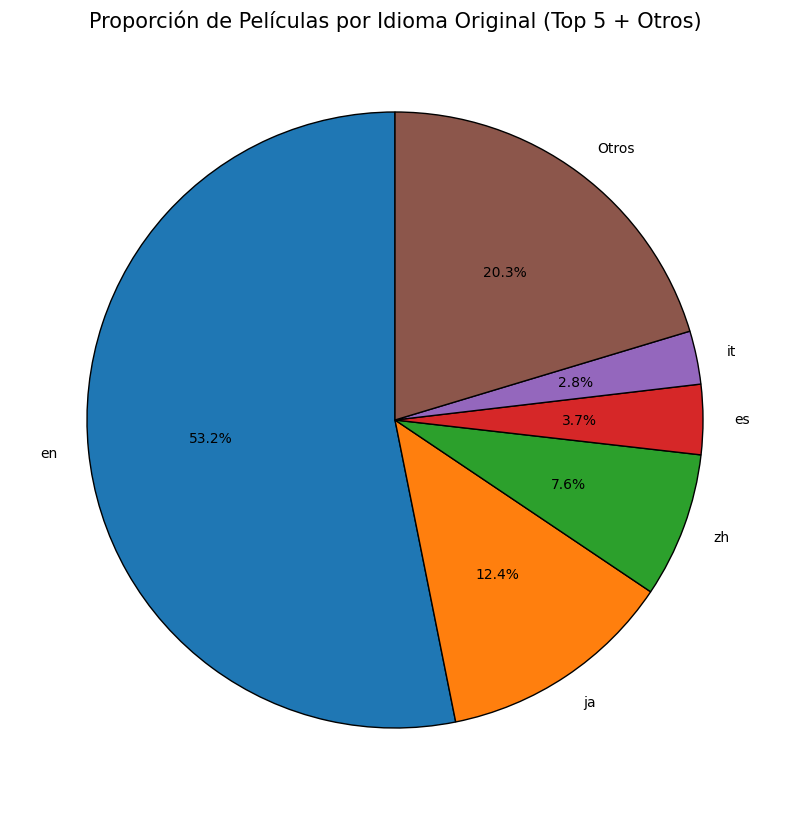

In [ ]:
# Contamos las ocurrencias de cada idioma original
conteo_idiomas = df['Original_Language'].value_counts()

# Seleccionamos los top 5 idiomas
top_5_idiomas_conteo = conteo_idiomas.head(5)

# Calculamos la suma de los idiomas restantes para 'Otros'
otros_idiomas_conteo = pd.Series({'Otros': conteo_idiomas.iloc[5:].sum()})

# Combinamos los top 5 con 'Otros'
pie_data = pd.concat([top_5_idiomas_conteo, otros_idiomas_conteo])

plt.figure(figsize=(10, 10))
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%',
        startangle=90, wedgeprops={'edgecolor': 'black'})

plt.title('Proporción de Películas por Idioma Original (Top 5 + Otros)', fontsize=15)
plt.show()

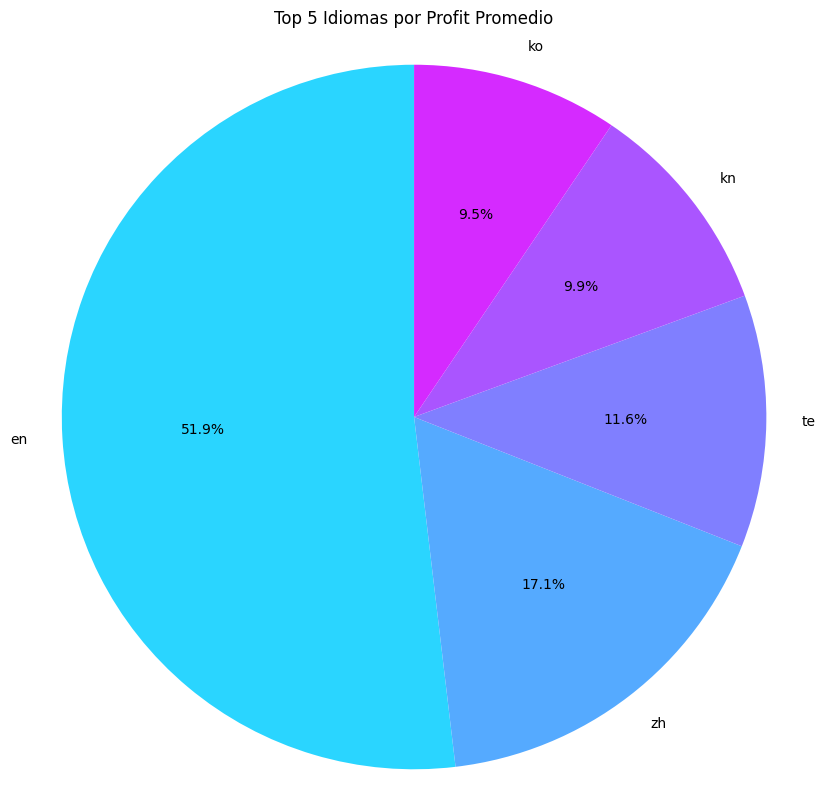

In [ ]:
# Generamos analisis_idioma para el gráfico
analisis_idioma = df_limpio.groupby('Original_Language')['Profit'].mean().reset_index()
analisis_idioma = analisis_idioma.sort_values(by='Profit', ascending=False)

# Obtener los top 5 y top 10 para evitar llamadas repetidas a .head()
top_5_idiomas = analisis_idioma.head(5)
top_10_idiomas = analisis_idioma.head(10)

# Visualizamos los 5 idiomas con mayor profit promedio (torta)
plt.figure(figsize=(10, 10))
plt.pie(top_5_idiomas['Profit'], labels=top_5_idiomas['Original_Language'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('cool', 5))
plt.title('Top 5 Idiomas por Profit Promedio')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

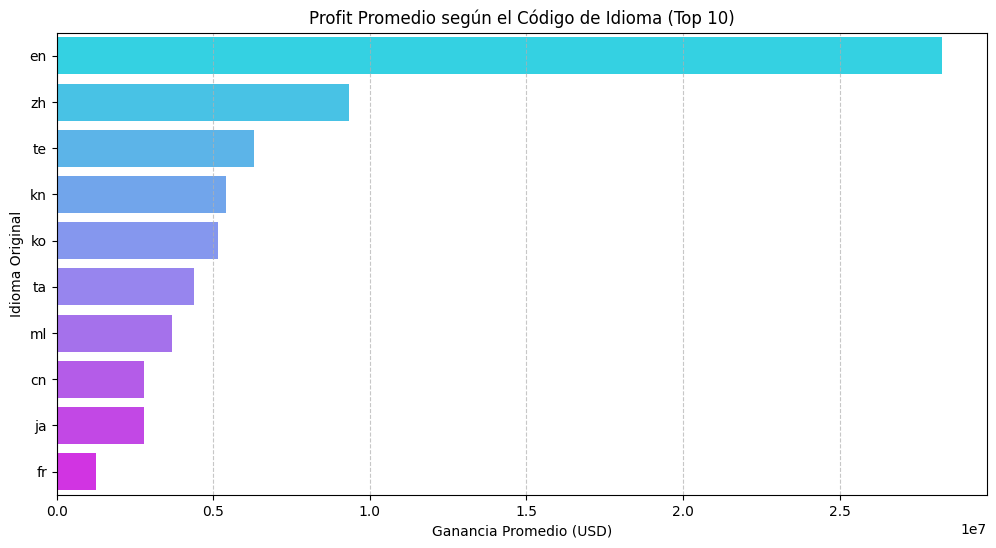

In [ ]:
# Visualizamos los 10 idiomas con mayor profit promedio (barras)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_idiomas, x='Profit', y='Original_Language', hue='Original_Language', palette='cool', legend=False)
plt.title('Profit Promedio según el Código de Idioma (Top 10)')
plt.xlabel('Ganancia Promedio (USD)')
plt.ylabel('Idioma Original')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

##Analisis de Profit promedio por Duración de una pelicula


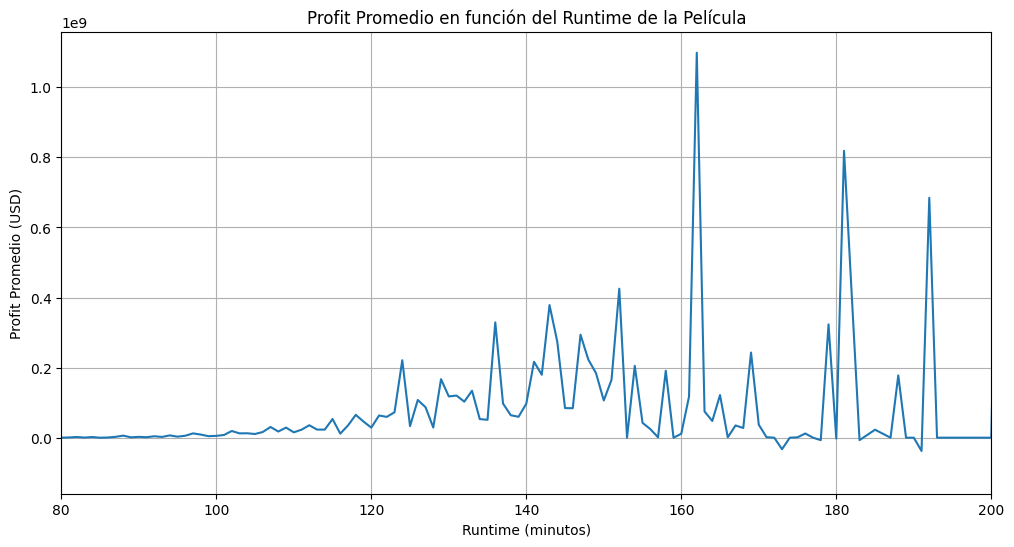

In [ ]:
# Calculamos el profit promedio por Runtime
profit_por_runtime = df_limpio.groupby('Runtime')['Profit'].mean().reset_index()

# Visualizamos la relación entre Runtime y Profit promedio
plt.figure(figsize=(12, 6))
sns.lineplot(data=profit_por_runtime, x='Runtime', y='Profit')
plt.title('Profit Promedio en función del Runtime de la Película')
plt.xlabel('Runtime (minutos)')
plt.ylabel('Profit Promedio (USD)')
plt.grid(True)
plt.xlim(80, 200) # Ajustamos los límites del eje X para enfocar en la zona de mayor fluctuación
plt.show()


##Analisis de Profit Promedio por Presupuesto

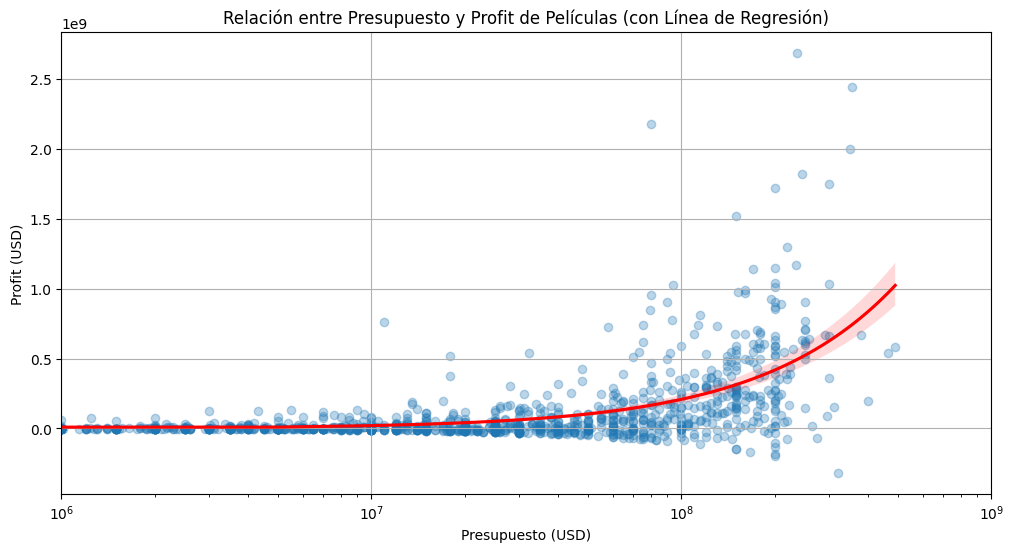

In [ ]:
# Visualizamos la relación entre Budget y Profit usando un gráfico de dispersión con línea de regresión
plt.figure(figsize=(12, 6))
sns.regplot(data=df_limpio, x='Budget', y='Profit', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relación entre Presupuesto y Profit de Películas (con Línea de Regresión)')
plt.xlabel('Presupuesto (USD)')
plt.ylabel('Profit (USD)')
plt.grid(True)
plt.xscale('log') # Usar escala logarítmica para el presupuesto
plt.xlim(10e5, 10e8) # Ajustamos los límites del eje X para enfocar en la zona relevante
plt.show()


Ahora incluiremos el año donde fueron lanzadas las peliculas y como fluctuan los presupuesto mediante el pasar del tiempo

In [ ]:
#Convertimos la columna a objeto datetime y extraemos el año
#para poder agrupar los datos económicamente.
df_limpio['Release_Date'] = pd.to_datetime(df_limpio['Release_Date'])
df_limpio['Year'] = df_limpio['Release_Date'].dt.year

In [ ]:
#Agrupamos por año para ver el promedio de presupuesto e ingresos
tendencia_anual = df_limpio.groupby('Year')[['Budget', 'Revenue']].mean().reset_index()

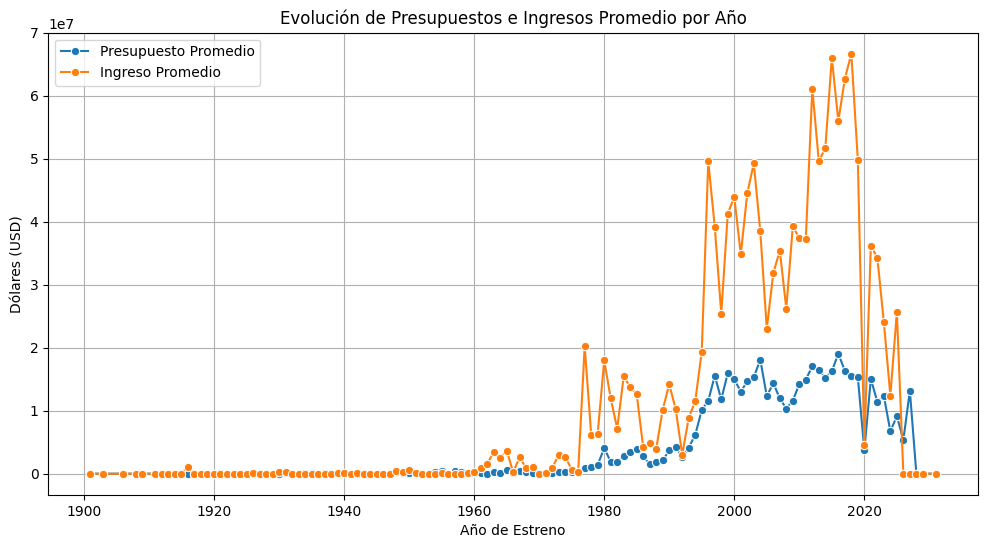

In [ ]:
#Visualización de la evolución
plt.figure(figsize=(12, 6))
sns.lineplot(data=tendencia_anual, x='Year', y='Budget', label='Presupuesto Promedio', marker='o')
sns.lineplot(data=tendencia_anual, x='Year', y='Revenue', label='Ingreso Promedio', marker='o')
plt.title('Evolución de Presupuestos e Ingresos Promedio por Año')
plt.ylabel('Dólares (USD)')
plt.xlabel('Año de Estreno')
plt.grid(True)
plt.legend()
plt.show()

Podemos ver un crecimiento en el Budget promedio por año que tienen las peliculas y las ganancias que presentan estas según la epoca.

No basta con ver cuánto dinero entró en total, lo que realmente cuenta para el negocio es cuánto queda de ganancia real después de los gastos. Por eso, para nuestro análisis calculamos el Profit restando lo que costó hacer la película de lo que recaudó en cines. Esto es clave porque nos permite encontrar cuáles películas fueron un buen negocio y cuáles terminaron en pérdida, sin importar si fueron muy famosas o populares


##Analisis sobre la cantidad de ganancias

In [ ]:
#Calculamos el Profit
#Justificación: Creamos la columna Profit para cuantificar el retorno económico real.
df_limpio['Profit'] = df_limpio['Revenue'] - df_limpio['Budget']

In [ ]:
#Obtener las 10 películas con más profit
top_10_profit = df_limpio.nlargest(10, 'Profit')[['Title', 'Budget', 'Revenue', 'Profit']]

In [ ]:
#Mostramos las tablas de resultados
display(top_10_profit)

,Title,Budget,Revenue,Profit
13,Avatar,237000000,2923706026,2686706026
28,Avengers: Endgame,356000000,2799439100,2443439100
23,Ne Zha 2,80000000,2259822417,2179822417
20,Avatar: The Way of Water,350000000,2353096253,2003096253
102,Star Wars: The Force Awakens,245000000,2068223624,1823223624
9,Avengers: Infinity War,300000000,2052415039,1752415039
8,Spider-Man: No Way Home,200000000,1921847111,1721847111
104,Jurassic World,150000000,1671537444,1521537444
5,The Avengers,220000000,1518815515,1298815515
41,Avengers: Age of Ultron,235000000,1405403694,1170403694


In [ ]:
#Obtener las 10 películas con menos profit (mayores pérdidas)
bottom_10_profit = df_limpio.nsmallest(10, 'Profit')[['Title', 'Budget', 'Revenue', 'Profit']]

In [ ]:
display(bottom_10_profit)


,Title,Budget,Revenue,Profit
120,The Electric State,320000000,0,-320000000
7422,Angry Birds Plush: Egg Trilogy,200000000,0,-200000000
67,The Tomorrow War,200000000,14400000,-185600000
289,Star Wars: The Mandalorian and Grogu,166400000,0,-166400000
353,Vāranāsi,150000000,0,-150000000
411,The Hunger Games: Sunrise on the Reaping,150000000,0,-150000000
169,Mulan,200000000,69965374,-130034626
465,Triple Frontier,115000000,0,-115000000
372,Argylle,200000000,96221061,-103778939
999,Mighty Joe Young,90000000,0,-90000000


Podemos observar que películas como 'Avatar' lideran el ranking con ganancias que superan los 2.6 billones de dólares, mientras que en el grupo de menores beneficios encontramos producciones cuyos ingresos no lograron cubrir la inversión inicial del Budget

Para visualizar la brecha financiera, crearemos un gráfico de barras horizontal consolidado. Utilizaremos colores diferenciados (verde para ganancias y rojo para pérdidas) para facilitar la interpretación visual de la salud económica de estas producciones de alto perfil.

In [ ]:
#Combinamos ambos grupos para el gráfico
extremos = pd.concat([top_10_profit, bottom_10_profit]).sort_values('Profit', ascending=False)

## Análisis del Promedio de Ganancias por Género

Para entender qué géneros son más rentables en promedio, vamos a desagregar la columna 'Genres' (que puede contener múltiples géneros por película), y luego calcularemos el 'Profit' promedio para cada uno.

/tmp/ipykernel_3578/107789389.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=average_profit_by_genre, x='Profit', y='Genre', palette='viridis')


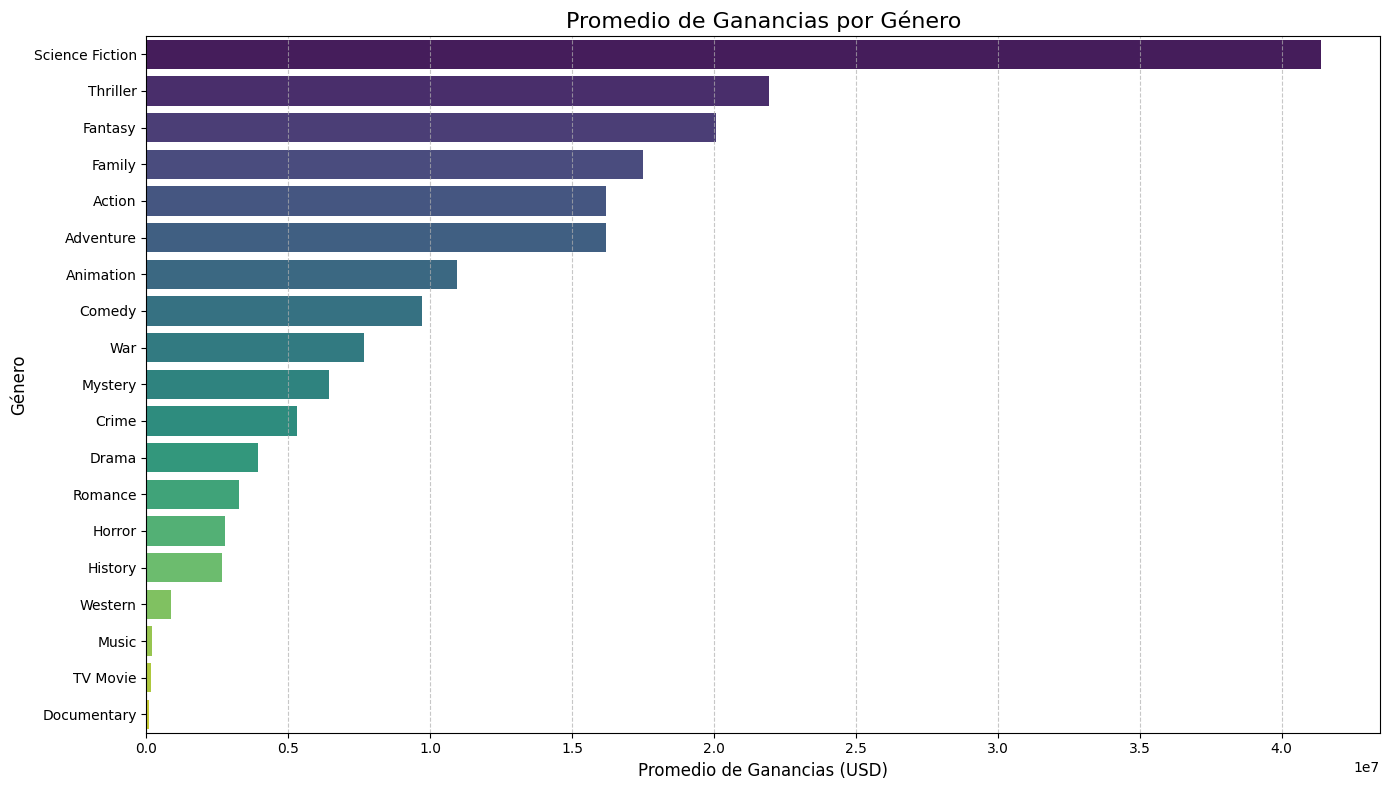

In [ ]:
# Preprocesar la columna 'Genres' para manejar múltiples géneros por película
# Crear una lista de todos los géneros únicos
all_genres = df_limpio['Genres'].str.split(', ').explode().unique()

# Crear un DataFrame auxiliar para el análisis de géneros y profit
genre_profit_list = []
for index, row in df_limpio.iterrows():
    genres_in_movie = row['Genres'].split(', ')
    for genre in genres_in_movie:
        genre_profit_list.append({'Genre': genre, 'Profit': row['Profit']})

df_genre_profit = pd.DataFrame(genre_profit_list)

# Calcular el promedio de profit por género
average_profit_by_genre = df_genre_profit.groupby('Genre')['Profit'].mean().sort_values(ascending=False).reset_index()

# Visualizar el promedio de ganancias por género
plt.figure(figsize=(14, 8))
sns.barplot(data=average_profit_by_genre, x='Profit', y='Genre', palette='viridis')
plt.title('Promedio de Ganancias por Género', fontsize=16)
plt.xlabel('Promedio de Ganancias (USD)', fontsize=12)
plt.ylabel('Género', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Interpretación: Este gráfico muestra el promedio de ganancias que genera cada género de película, lo que nos permite identificar los géneros más lucrativos en la industria cinematográfica.

/tmp/ipykernel_3578/2446270420.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=extremos, x='Profit', y='Title', palette=colors)


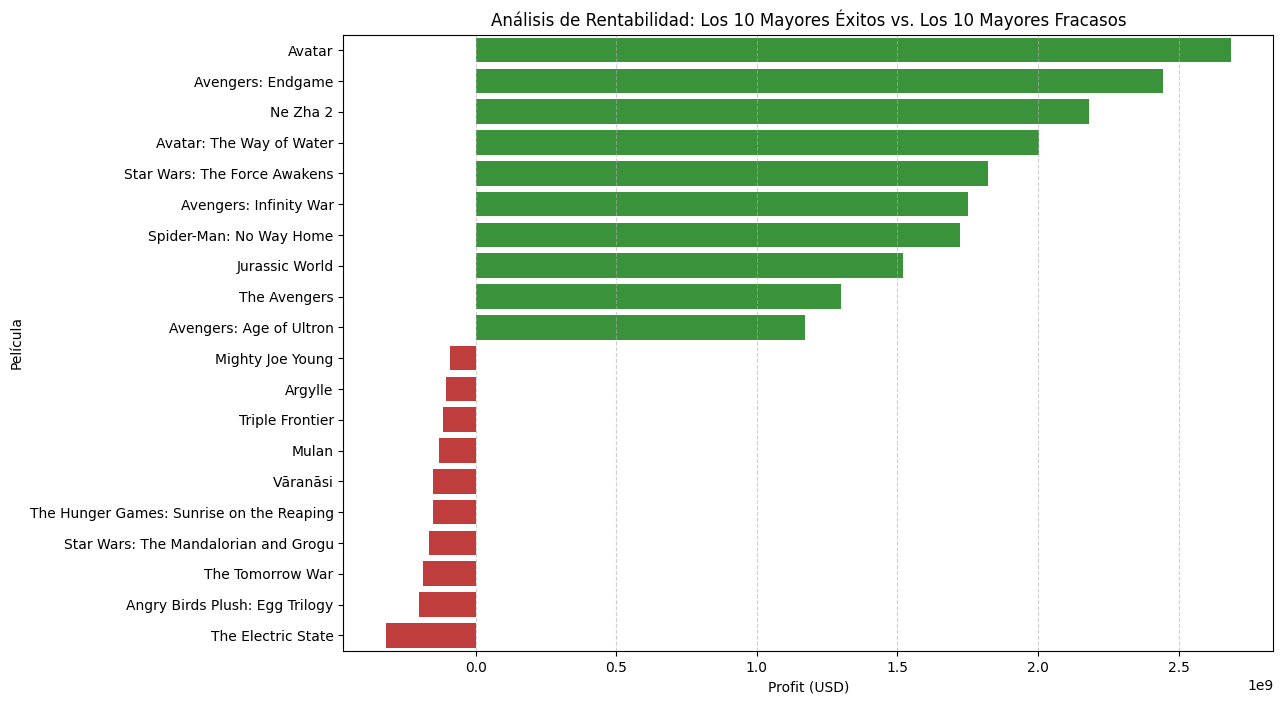

In [ ]:
plt.figure(figsize=(12, 8))
# Asignamos colores: verde para profit positivo, rojo para negativo
colors = ['#2ca02c' if x > 0 else '#d62728' for x in extremos['Profit']]

sns.barplot(data=extremos, x='Profit', y='Title', palette=colors)
plt.title('Análisis de Rentabilidad: Los 10 Mayores Éxitos vs. Los 10 Mayores Fracasos')
plt.xlabel('Profit (USD)')
plt.ylabel('Película')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
df.describe()

,ID,Popularity,Vote_Average,Vote_Count,Runtime,Budget,Revenue,Original_Lenguaje_Encoded
count,8.121000e+03,8121.000000,8121.000000,8121.000000,8121.000000,8.121000e+03,8.121000e+03,8121.000000
mean,5.377308e+05,1.220255,4.130074,469.181505,78.123507,7.941100e+06,2.340326e+07,24.480113
std,4.888729e+05,2.891697,2.992888,2314.023411,50.077687,3.293861e+07,1.285246e+08,18.351746
min,1.100000e+01,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,1.030480e+05,0.226700,0.000000,0.000000,51.000000,0.000000e+00,0.000000e+00,13.000000
50%,3.995660e+05,0.528300,5.000000,3.000000,88.000000,0.000000e+00,0.000000e+00,13.000000
75%,8.784140e+05,1.152300,6.380000,33.000000,101.000000,0.000000e+00,0.000000e+00,29.000000
max,1.655003e+06,81.596700,10.000000,38855.000000,999.000000,4.899000e+08,2.923706e+09,69.000000


##Analisis de correlación sobre Ganancias

In [ ]:
Ahora me gustaría hacer una analisis de correlación sobre los aspectos que se han comparado con los profits osea (runtime, budget, genre, Original_lenguaje)

In [ ]:
# Para el análisis de correlación, necesitamos asegurarnos de que la columna 'Original_Lenguaje_Encoded' esté en el DataFrame `df_limpio`.
# Actualmente, 'Original_Lenguaje_Encoded' se creó en `df`. Necesitamos transferirla o recrearla en `df_limpio`.
# Dada que la codificación es sobre 'Original_Language', podemos aplicarla directamente a `df_limpio`.

# Primero, asegurémonos de que `df_limpio` tiene la columna 'Original_Language'.
# Luego, creamos una instancia de LabelEncoder y la aplicamos a la columna 'Original_Language' de `df_limpio`.
from sklearn.preprocessing import LabelEncoder

# Asegurarse de que `df_limpio` tenga la columna 'Original_Language'
if 'Original_Language' in df_limpio.columns:
    label_encoder_limpio = LabelEncoder()
    df_limpio['Original_Lenguaje_Encoded'] = label_encoder_limpio.fit_transform(df_limpio['Original_Language'])
    print("Columna 'Original_Lenguaje_Encoded' creada en df_limpio.")
else:
    print("La columna 'Original_Language' no está presente en df_limpio.")

# Seleccionamos las columnas numéricas relevantes para el análisis de correlación
# Incluimos 'Original_Lenguaje_Encoded' ya que es una representación numérica de la categoría
correlation_columns = ['Profit', 'Runtime', 'Budget', 'Original_Lenguaje_Encoded']

# Calculamos la matriz de correlación
correlation_matrix = df_limpio[correlation_columns].corr()

# Mostramos la matriz de correlación
print("\nMatriz de Correlación:")
display(correlation_matrix)


Columna 'Original_Lenguaje_Encoded' creada en df_limpio.

Matriz de Correlación:


,Profit,Runtime,Budget,Original_Lenguaje_Encoded
Profit,1.000000,0.163998,0.659307,-0.070170
Runtime,0.163998,1.000000,0.221797,-0.048310
Budget,0.659307,0.221797,1.000000,-0.127208
Original_Lenguaje_Encoded,-0.070170,-0.048310,-0.127208,1.000000


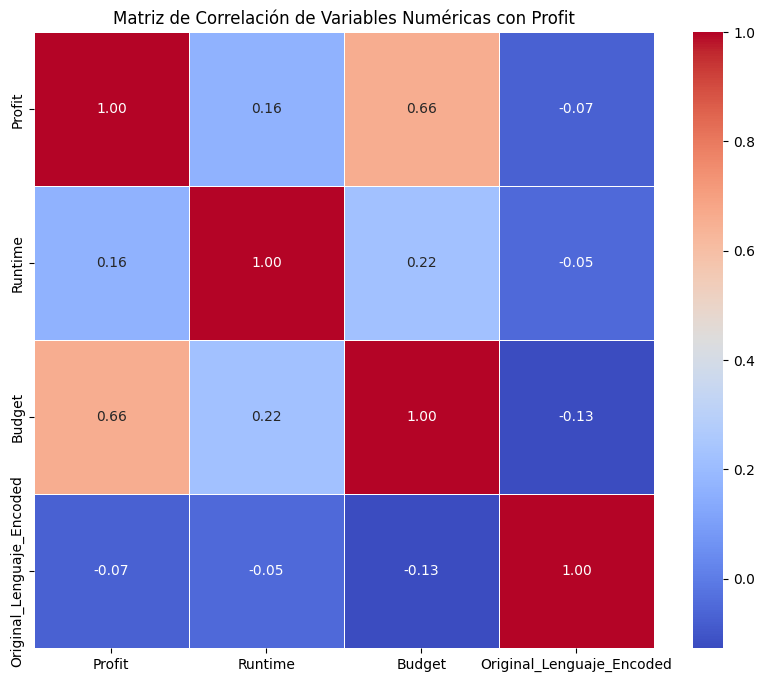

In [ ]:
# Visualizamos la matriz de correlación con un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas con Profit')
plt.show()


En este mapa de calor, podemos ver cómo se correlacionan las variables numéricas entre sí. Los valores cercanos a 1 o -1 indican una correlación fuerte (positiva o negativa respectivamente), mientras que los cercanos a 0 indican una correlación débil.

Para las variables categóricas como 'Genres', ya hemos explorado el 'Promedio de Ganancias por Género' en un gráfico anterior. Este tipo de análisis, que muestra la ganancia promedio por cada categoría, es una forma efectiva de entender su relación con el profit, ya que una correlación directa (como la de Pearson) no es adecuada para variables categóricas.

Utilizaremos un algoritmo de ensamble para identificar qué variables tienen mayor peso estadístico.


Importancia de las Características (RandomForest):


,0
Budget,0.686661
Runtime,0.309021
Original_Lenguaje_Encoded,0.004318


/tmp/ipykernel_3578/1062501477.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis')


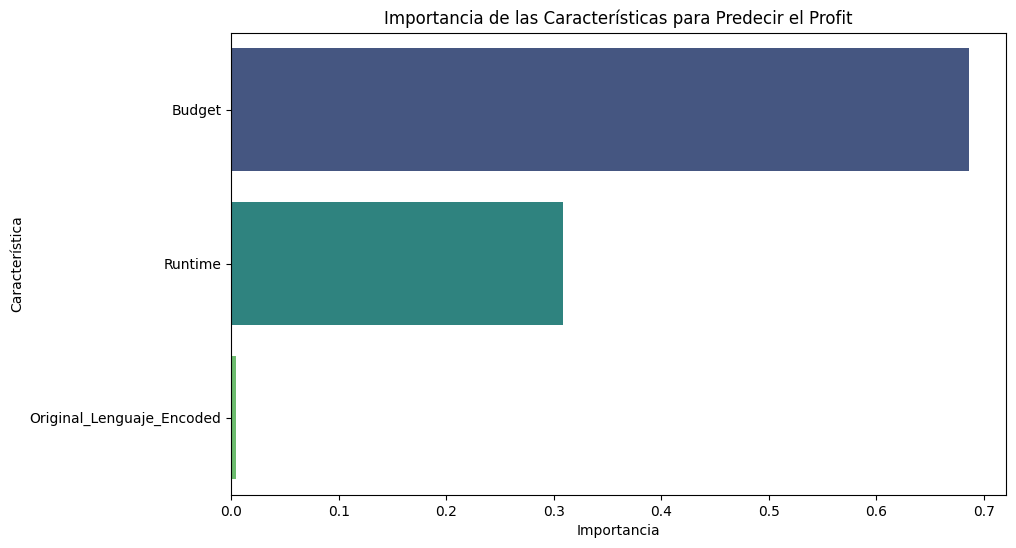

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Preparamos los datos para el modelo
# Definimos las características (X) y la variable objetivo (y)
# Incluimos las columnas numéricas que hemos analizado, incluyendo la codificación del lenguaje.
X = df_limpio[['Runtime', 'Budget', 'Original_Lenguaje_Encoded']]
y = df_limpio['Profit']

# Manejamos posibles valores NaN en X. Para RandomForest, podemos simplemente rellenar con la media si no hay muchos, o eliminar filas si son pocas.
# Para este ejemplo, rellenaremos con la media si existen NaN, aunque df_limpio ya debería estar bastante limpio.
X = X.fillna(X.mean())

# Dividimos los datos en conjuntos de entrenamiento y prueba (opcional, pero buena práctica)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creamos y entrenamos el modelo RandomForestRegressor
# Aumentamos n_estimators para una mayor estabilidad en las importancias de las características.
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 usa todos los núcleos disponibles
model.fit(X_train, y_train)

# Obtenemos la importancia de las características
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nImportancia de las Características (RandomForest):")
display(feature_importances)

# Visualizamos la importancia de las características
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis')
plt.title('Importancia de las Características para Predecir el Profit')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()


Este gráfico de barras nos muestra la importancia relativa de cada característica (`Runtime`, `Budget`, `Original_Lenguaje_Encoded`) según el modelo `RandomForestRegressor`. Cuanto más larga sea la barra, más influyente es esa característica para determinar el 'Profit'.

Como mencionamos anteriormente, para variables categóricas como `Genres`, que pueden tener múltiples valores por película, el análisis de importancia de características dentro de un modelo de ensamble es más complejo si se incluyen directamente como categorías multi-etiqueta. La forma más adecuada de incluirlas es mediante la creación de variables dummy (one-hot encoding) para cada género, lo cual podría aumentar significativamente la dimensionalidad del modelo, o continuar analizando su impacto a través del promedio de ganancias por género, como ya lo hicimos.

git config --global user.email vi.vilchesm@duocuc.cl
git config --global user.name vivilchesm-rgb